# Compare KD No-Weights Experiments

This notebook compares the no-weight KD communication channels prepared under `kd-experiments-without-weights`.

It now includes a dedicated section for **soft labels**, with the same kind of run aggregation used in the KD and FedAvg summaries: mean +/- sample standard deviation across runs, ranked by final global test PR-AUC.

In [7]:
from pathlib import Path
import json
import sys
import pandas as pd
import numpy as np

try:
    from IPython.display import display
except Exception:
    display = print

def find_no_weights_root() -> Path:
    cwd = Path.cwd()
    if cwd.name == 'kd-experiments-without-weights':
        return cwd
    candidate = cwd / 'kd-experiments-without-weights'
    if candidate.exists():
        return candidate
    for parent in cwd.parents:
        candidate = parent / 'kd-experiments-without-weights'
        if candidate.exists():
            return candidate
    raise FileNotFoundError('Could not locate kd-experiments-without-weights from the current working directory.')

ROOT = find_no_weights_root()
REPO_ROOT = ROOT.parent
KD_ROOT = REPO_ROOT / 'kd-experiments'
if str(KD_ROOT) not in sys.path:
    sys.path.insert(0, str(KD_ROOT))

CHANNELS = ['soft labels', 'hidden states', 'class prototype']
METRIC_ORDER = ['accuracy', 'balanced_accuracy', 'specificity', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc', 'far', 'miss_rate']

try:
    from config import EXPERIMENT_CATALOG
    EXPERIMENT_IDS = list(EXPERIMENT_CATALOG.keys())
except Exception:
    EXPERIMENT_CATALOG = {}
    EXPERIMENT_IDS = [
        'exp1_kkd_base', 'exp2_fraction_clients', 'exp3_local_epochs', 'exp4_unweighted_aggregation',
        'exp5_cross_dataset', 'exp6_keep_best_local_model', 'exp7_clustered_aggregation', 'exp8_personalized_fedavg',
        'exp9_final_local_finetuning', 'exp10_clustered_keep_best_local', 'exp11_baseline_final',
        'exp12_final_unweighted', 'exp13_final_keep_best_local', 'exp14_final_clustered',
    ]

ROOT

WindowsPath('c:/Users/leono/Desktop/iscte/Tese/FL_MasterThesis/kd-experiments-without-weights')

In [8]:
def read_json(path: Path) -> dict:
    if not path.exists():
        return {}
    return json.loads(path.read_text(encoding='utf-8'))

def safe_float(value):
    if value is None:
        return np.nan
    try:
        return float(value)
    except (TypeError, ValueError):
        return value

def flatten_metrics(row: dict, payload: dict, prefix: str) -> None:
    for key, value in payload.items():
        row[f'{prefix}_{key}'] = safe_float(value)

def expected_config_matches(experiment_id: str, cfg: dict, channel: str) -> bool:
    expected = EXPERIMENT_CATALOG.get(experiment_id)
    if expected is None:
        return True
    if int(cfg.get('num_rounds', -1)) != int(expected.num_rounds):
        return False
    if int(cfg.get('local_epochs', -1)) != int(expected.local_epochs):
        return False
    if channel == 'soft labels' and cfg.get('communication_mode') not in {'soft_labels', None}:
        return False
    return True

def load_runs_for_channel(channel: str, full_config_only: bool = True) -> pd.DataFrame:
    channel_path = ROOT / channel
    rows = []
    if not channel_path.exists():
        return pd.DataFrame()
    for exp_dir in sorted([p for p in channel_path.iterdir() if p.is_dir()]):
        results_root = exp_dir / 'results'
        if not results_root.exists():
            continue
        for run_dir in sorted([d for d in results_root.iterdir() if d.is_dir()]):
            cfg = read_json(run_dir / 'config.json')
            summary = read_json(run_dir / 'run_summary.json')
            if not summary:
                continue
            if full_config_only and not expected_config_matches(exp_dir.name, cfg, channel):
                continue
            if not summary.get('dev_metrics') and not summary.get('test_metrics'):
                continue

            row = {
                'channel': channel,
                'experiment_id': exp_dir.name,
                'run_name': run_dir.name,
                'run_path': str(run_dir),
                'title': summary.get('title') or cfg.get('title') or exp_dir.name,
                'description': summary.get('description') or cfg.get('description') or '',
                'communication_mode': summary.get('communication_mode') or cfg.get('communication_mode') or channel.replace(' ', '_'),
                'communicates_model_weights': summary.get('communicates_model_weights', cfg.get('communicates_model_weights', False)),
            }

            for key, value in cfg.items():
                if isinstance(value, dict):
                    for subkey, subvalue in value.items():
                        row[f'model_{subkey}'] = safe_float(subvalue)
                else:
                    row[key] = safe_float(value)

            flatten_metrics(row, summary.get('dev_metrics', {}), 'dev')
            flatten_metrics(row, summary.get('test_metrics', {}), 'test')
            flatten_metrics(row, summary.get('local_metrics_summary', {}), 'local')
            flatten_metrics(row, summary.get('fine_tune_summary', {}), 'fine_tune')
            rows.append(row)
    return pd.DataFrame(rows)

def aggregate_runs(runs_df: pd.DataFrame) -> pd.DataFrame:
    if runs_df.empty:
        return pd.DataFrame()
    numeric_cols = runs_df.select_dtypes(include=['number']).columns.tolist()
    metadata_cols = [
        'channel', 'experiment_id', 'title', 'description', 'scenario', 'num_rounds', 'local_epochs',
        'fraction_fit', 'weighted_aggregation', 'local_model_selection', 'clustered_aggregation',
        'personalized_head', 'final_local_finetune_epochs', 'communication_mode', 'communicates_model_weights',
        'model_hidden_layers', 'model_dropout', 'model_learning_rate', 'model_weight_decay', 'model_batch_size',
    ]
    metadata_cols = [col for col in metadata_cols if col in runs_df.columns]
    rows = []
    for (channel, experiment_id), group in runs_df.groupby(['channel', 'experiment_id'], sort=False):
        row = {'channel': channel, 'experiment_id': experiment_id, 'n_runs': int(len(group))}
        for col in metadata_cols:
            if col in group.columns:
                row[col] = group.iloc[0][col]
        for col in numeric_cols:
            series = pd.to_numeric(group[col], errors='coerce').dropna()
            if series.empty:
                continue
            row[f'{col}_mean'] = float(series.mean())
            row[f'{col}_std'] = float(series.std(ddof=1)) if len(series) > 1 else 0.0
        rows.append(row)
    return pd.DataFrame(rows)

def sort_by_test_performance(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df
    return df.sort_values(['test_pr_auc_mean', 'test_f1_mean'], ascending=[False, False], na_position='last').reset_index(drop=True)

## Overview Across No-Weight Channels

This optional overview loads all available no-weight channels and ranks experiments within each channel. The soft-label section below is the one to use for the thesis-style summary file.

In [9]:
all_runs = []
for channel in CHANNELS:
    channel_df = load_runs_for_channel(channel, full_config_only=True)
    if not channel_df.empty:
        all_runs.append(channel_df)

results_df = pd.concat(all_runs, ignore_index=True) if all_runs else pd.DataFrame()
channel_agg = sort_by_test_performance(aggregate_runs(results_df)) if not results_df.empty else pd.DataFrame()

display_cols = ['channel', 'experiment_id', 'n_runs', 'test_pr_auc_mean', 'test_pr_auc_std', 'test_f1_mean', 'test_f1_std']
channel_agg[[col for col in display_cols if col in channel_agg.columns]].head(30)

,channel,experiment_id,n_runs,test_pr_auc_mean,test_pr_auc_std,test_f1_mean,test_f1_std
0,soft labels,exp12_final_unweighted,10,0.731992,0.005513,0.601578,0.007358
1,soft labels,exp11_baseline_final,10,0.731836,0.004723,0.618119,0.008782
2,soft labels,exp14_final_clustered,10,0.731141,0.006186,0.618162,0.008846
3,soft labels,exp13_final_keep_best_local,10,0.730804,0.004808,0.618085,0.008522
4,soft labels,exp1_kkd_base,10,0.681431,0.007030,0.572512,0.008539
5,soft labels,exp3_local_epochs,10,0.680324,0.006517,0.570476,0.011607
6,soft labels,exp6_keep_best_local_model,10,0.680047,0.005691,0.570909,0.009015
7,soft labels,exp7_clustered_aggregation,10,0.679945,0.006571,0.570630,0.010548
8,soft labels,exp8_personalized_fedavg,10,0.679687,0.004516,0.572536,0.009653
9,soft labels,exp10_clustered_keep_best_local,10,0.677312,0.009148,0.568504,0.009783


In [10]:
if channel_agg.empty:
    print('No complete no-weight runs found yet.')
else:
    top3_by_channel = (
        channel_agg
        .sort_values(['channel', 'test_pr_auc_mean', 'test_f1_mean'], ascending=[True, False, False], na_position='last')
        .groupby('channel', group_keys=False)
        .head(3)
    )
    channel_scores = (
        top3_by_channel
        .groupby('channel', as_index=False)['test_pr_auc_mean']
        .mean()
        .rename(columns={'test_pr_auc_mean': 'mean_top3_test_pr_auc'})
        .sort_values('mean_top3_test_pr_auc', ascending=False)
        .reset_index(drop=True)
    )
    display(channel_scores)
    display(top3_by_channel[[col for col in display_cols if col in top3_by_channel.columns]])

,channel,mean_top3_test_pr_auc
0,soft labels,0.731656


,channel,experiment_id,n_runs,test_pr_auc_mean,test_pr_auc_std,test_f1_mean,test_f1_std
0,soft labels,exp12_final_unweighted,10,0.731992,0.005513,0.601578,0.007358
1,soft labels,exp11_baseline_final,10,0.731836,0.004723,0.618119,0.008782
2,soft labels,exp14_final_clustered,10,0.731141,0.006186,0.618162,0.008846


## Soft Labels Experiments

This section compares only `kd-experiments-without-weights/soft labels`.

These runs do **not** communicate model weights. Each client sends a soft-label KD payload, the server aggregates that payload, and the next round sends the aggregated soft-label signal back to the clients.

In [11]:
soft_runs_df = load_runs_for_channel('soft labels', full_config_only=True)
soft_agg = sort_by_test_performance(aggregate_runs(soft_runs_df))

print(f'Soft-label complete runs loaded: {len(soft_runs_df)}')
if soft_runs_df.empty:
    print('No complete soft-label runs found.')
else:
    counts = soft_runs_df.groupby('experiment_id').size().reindex(EXPERIMENT_IDS).dropna().astype(int)
    display(counts.rename('n_runs').to_frame())

Soft-label complete runs loaded: 140


,n_runs
experiment_id,
exp1_kkd_base,10
exp2_fraction_clients,10
exp3_local_epochs,10
exp4_unweighted_aggregation,10
exp5_cross_dataset,10
exp6_keep_best_local_model,10
exp7_clustered_aggregation,10
exp8_personalized_fedavg,10
exp9_final_local_finetuning,10


In [12]:
soft_display_cols = [
    'experiment_id', 'n_runs', 'num_rounds', 'local_epochs', 'weighted_aggregation',
    'local_model_selection', 'clustered_aggregation', 'personalized_head',
    'test_pr_auc_mean', 'test_pr_auc_std', 'test_f1_mean', 'test_f1_std',
    'test_miss_rate_mean', 'test_miss_rate_std', 'test_far_mean', 'test_far_std',
]
soft_agg[[col for col in soft_display_cols if col in soft_agg.columns]]

,experiment_id,n_runs,num_rounds,local_epochs,weighted_aggregation,local_model_selection,clustered_aggregation,personalized_head,test_pr_auc_mean,test_pr_auc_std,test_f1_mean,test_f1_std,test_miss_rate_mean,test_miss_rate_std,test_far_mean,test_far_std
0,exp12_final_unweighted,10,25.0,100.0,0.0,0.0,0.0,0.0,0.731992,0.005513,0.601578,0.007358,0.424713,0.008248,0.084265,0.003755
1,exp11_baseline_final,10,25.0,100.0,1.0,0.0,0.0,0.0,0.731836,0.004723,0.618119,0.008782,0.397456,0.012007,0.091889,0.005483
2,exp14_final_clustered,10,25.0,100.0,1.0,0.0,1.0,0.0,0.731141,0.006186,0.618162,0.008846,0.397995,0.011139,0.091993,0.003432
3,exp13_final_keep_best_local,10,25.0,100.0,1.0,1.0,0.0,0.0,0.730804,0.004808,0.618085,0.008522,0.398571,0.011609,0.091692,0.004076
4,exp1_kkd_base,10,25.0,10.0,1.0,0.0,0.0,0.0,0.681431,0.007030,0.572512,0.008539,0.422774,0.017034,0.131152,0.008248
5,exp3_local_epochs,10,25.0,10.0,1.0,0.0,0.0,0.0,0.680324,0.006517,0.570476,0.011607,0.424267,0.023858,0.131034,0.012852
6,exp6_keep_best_local_model,10,25.0,10.0,1.0,1.0,0.0,0.0,0.680047,0.005691,0.570909,0.009015,0.424611,0.018253,0.131165,0.007923
7,exp7_clustered_aggregation,10,25.0,10.0,1.0,0.0,1.0,0.0,0.679945,0.006571,0.570630,0.010548,0.422522,0.020052,0.131982,0.010121
8,exp8_personalized_fedavg,10,25.0,10.0,1.0,0.0,0.0,1.0,0.679687,0.004516,0.572536,0.009653,0.419004,0.019201,0.133089,0.011284
9,exp10_clustered_keep_best_local,10,25.0,10.0,1.0,1.0,1.0,0.0,0.677312,0.009148,0.568504,0.009783,0.424114,0.016678,0.133370,0.009242


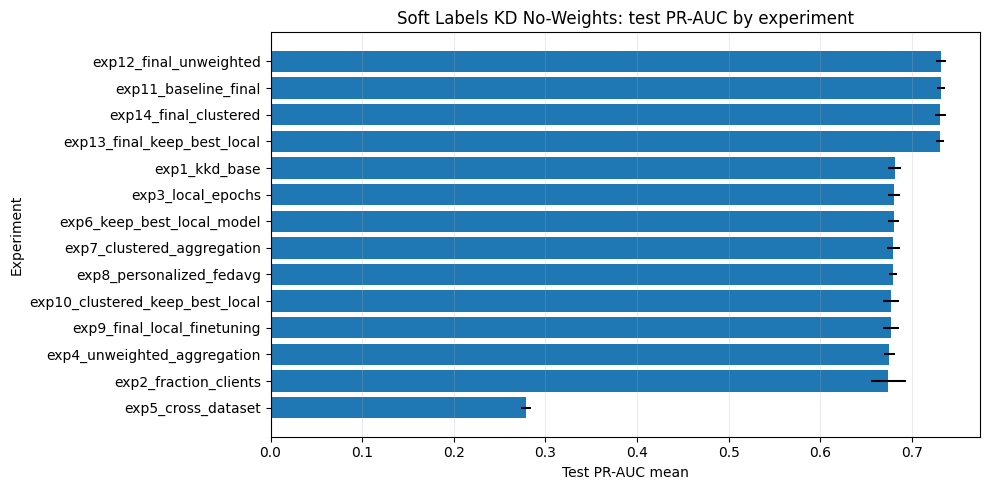

In [13]:
if not soft_agg.empty:
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        print('matplotlib is not installed; skipping plot.')
    else:
        plot_df = soft_agg.sort_values('test_pr_auc_mean', ascending=True)
        fig, ax = plt.subplots(figsize=(10, max(5, 0.35 * len(plot_df))))
        ax.barh(plot_df['experiment_id'], plot_df['test_pr_auc_mean'], xerr=plot_df.get('test_pr_auc_std'))
        ax.set_xlabel('Test PR-AUC mean')
        ax.set_ylabel('Experiment')
        ax.set_title('Soft Labels KD No-Weights: test PR-AUC by experiment')
        ax.grid(axis='x', alpha=0.25)
        plt.tight_layout()


In [14]:
def fmt_bool(value) -> str:
    if pd.isna(value):
        return '0'
    return str(int(bool(value)))

def fmt_value(value, digits=4) -> str:
    if value is None or pd.isna(value):
        return 'n/a'
    return f'{float(value):.{digits}f}'

def fmt_mean_std(row, prefix, metric) -> str:
    mean = row.get(f'{prefix}_{metric}_mean', np.nan)
    std = row.get(f'{prefix}_{metric}_std', np.nan)
    if pd.isna(mean):
        return 'n/a'
    if pd.isna(std):
        std = 0.0
    return f'{float(mean):.4f} +/- {float(std):.4f}'

def build_soft_labels_summary(soft_summary_df: pd.DataFrame) -> str:
    lines = [
        'Soft Labels KD No-Weights Experiments Summary',
        '=============================================',
        '',
        'Results are aggregated across all available complete runs for each experiment/variant.',
        'Uncertainty is reported as sample standard deviation across runs (mean +/- std).',
        '',
        'Knowledge Distillation Configuration:',
        '- Type: Response-based KD using aggregated soft-label payloads',
        '- Communication: no model weights are exchanged',
        '- Client payload: soft-label statistics from local model outputs',
        '- Server: aggregates soft-label payloads and sends the global soft-label signal in the next round',
        '- Student: local model being trained',
        '',
        'Ranked experiments by final global test PR-AUC:',
    ]

    ranked = sort_by_test_performance(soft_summary_df)
    for idx, row in ranked.iterrows():
        lines.append(
            f"  {idx + 1}. {row['experiment_id']} - test PR-AUC: {fmt_value(row.get('test_pr_auc_mean'))}, "
            f"test F1: {fmt_value(row.get('test_f1_mean'))}"
        )
    lines.append('')

    for _, row in ranked.iterrows():
        exp_id = str(row['experiment_id'])
        lines.extend([
            '',
            exp_id,
            '-' * len(exp_id),
            f"Title: {row.get('title', exp_id)}",
            f"Description: {row.get('description', '')}",
            f"Runs aggregated: {int(row.get('n_runs', 0))}",
            f"Global rounds: {int(row.get('num_rounds', 0)) if not pd.isna(row.get('num_rounds', np.nan)) else 'n/a'}",
            f"Local epochs: {int(row.get('local_epochs', 0)) if not pd.isna(row.get('local_epochs', np.nan)) else 'n/a'}",
            f"Weighted aggregation: {fmt_bool(row.get('weighted_aggregation', 0))}",
            f"Local model selection: {fmt_bool(row.get('local_model_selection', 0))}",
            f"Clustered aggregation: {fmt_bool(row.get('clustered_aggregation', 0))}",
            f"Personalized head: {fmt_bool(row.get('personalized_head', 0))}",
            f"Communicates model weights: {fmt_bool(row.get('communicates_model_weights', 0))}",
        ])
        if 'model_hidden_layers' in row and row.get('model_hidden_layers') is not None:
            lines.append(f"Model hidden layers: {row.get('model_hidden_layers')}")
        for label, key, digits in [
            ('Model dropout', 'model_dropout', 4),
            ('Model learning rate', 'model_learning_rate', 6),
            ('Model weight decay', 'model_weight_decay', 7),
            ('Model batch size', 'model_batch_size', 0),
        ]:
            if key in row and not pd.isna(row.get(key)):
                value = row.get(key)
                lines.append(f'{label}: {int(value) if digits == 0 else f"{float(value):.{digits}f}"}')

        lines.extend(['', 'Final global dev metrics:'])
        for metric in METRIC_ORDER:
            lines.append(f'  {metric}: {fmt_mean_std(row, "dev", metric)}')

        lines.extend(['', 'Final global test metrics:'])
        for metric in METRIC_ORDER:
            lines.append(f'  {metric}: {fmt_mean_std(row, "test", metric)}')

        fine_tune_available = any(
            f'fine_tune_{metric}_mean' in row.index and not pd.isna(row.get(f'fine_tune_{metric}_mean'))
            for metric in METRIC_ORDER
        )
        lines.extend(['', 'Final fine-tuned test-client metrics:'])
        if fine_tune_available:
            for metric in METRIC_ORDER:
                lines.append(f'  {metric}: {fmt_mean_std(row, "fine_tune", metric)}')
        else:
            lines.append('  n/a')

    return '\n'.join(lines).strip() + '\n'

if soft_agg.empty:
    print('No soft-label summary generated because no complete runs were found.')
else:
    summary_text = build_soft_labels_summary(soft_agg)
    output_path = ROOT / 'soft-labels_results.txt'
    output_path.write_text(summary_text, encoding='utf-8')
    print(f'Wrote {output_path}')
    print('\n'.join(summary_text.splitlines()[:25]))


Wrote c:\Users\leono\Desktop\iscte\Tese\FL_MasterThesis\kd-experiments-without-weights\soft-labels_results.txt
Soft Labels KD No-Weights Experiments Summary

Results are aggregated across all available complete runs for each experiment/variant.
Uncertainty is reported as sample standard deviation across runs (mean +/- std).

Knowledge Distillation Configuration:
- Type: Response-based KD using aggregated soft-label payloads
- Communication: no model weights are exchanged
- Client payload: soft-label statistics from local model outputs
- Server: aggregates soft-label payloads and sends the global soft-label signal in the next round
- Student: local model being trained

Ranked experiments by final global test PR-AUC:
  1. exp12_final_unweighted - test PR-AUC: 0.7320, test F1: 0.6016
  2. exp11_baseline_final - test PR-AUC: 0.7318, test F1: 0.6181
  3. exp14_final_clustered - test PR-AUC: 0.7311, test F1: 0.6182
  4. exp13_final_keep_best_local - test PR-AUC: 0.7308, test F1: 0.6181
  5. 